In [ ]:
 # Cell 2 — Load the data
import pandas as pd
import numpy as np

df = pd.read_csv('online_retail_II.csv')
print(df.shape)
display(df.head())

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Cell 3 — Diagnosis: audit the raw data for anomalies
raw_rows = len(df)
print("="*55)
print(f"RAW ROWS: {raw_rows:,}  |  COLUMNS: {df.shape[1]}")
print("="*55)

# Data types
print("\n--- DATA TYPES ---")
print(df.dtypes)

# Date range (InvoiceDate is still text at this point)
print("\n--- DATE RANGE ---")
print(df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())

# Anomaly audit
print("\n--- ANOMALY AUDIT ---")
audit = {
    "Null Description"          : df['Description'].isnull().sum(),
    "Null Customer ID"          : df['Customer ID'].isnull().sum(),
    "Negative Quantity"         : (df['Quantity'] < 0).sum(),
    "Zero Quantity"             : (df['Quantity'] == 0).sum(),
    "Negative Price"            : (df['Price'] < 0).sum(),
    "Zero Price"                : (df['Price'] == 0).sum(),
    "Full-row duplicates"       : df.duplicated().sum(),
    "Cancellation invoices (C)" : df['Invoice'].astype(str).str.startswith('C').sum(),
}
for label, count in audit.items():
    print(f"{label:28s}: {count:>8,}  ({count/raw_rows*100:5.2f}%)")

# Non-product / admin stock codes
print("\n--- NON-PRODUCT STOCK CODES (top 10) ---")
admin_mask = ~df['StockCode'].astype(str).str.match(r'^\d{5}')
print(df[admin_mask]['StockCode'].value_counts().head(10))

RAW ROWS: 1,067,371  |  COLUMNS: 8

--- DATA TYPES ---
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

--- DATE RANGE ---
2009-12-01 07:45:00 → 2011-12-09 12:50:00

--- ANOMALY AUDIT ---
Null Description            :    4,382  ( 0.41%)
Null Customer ID            :  243,007  (22.77%)
Negative Quantity           :   22,950  ( 2.15%)
Zero Quantity               :        0  ( 0.00%)
Negative Price              :        5  ( 0.00%)
Zero Price                  :    6,202  ( 0.58%)
Full-row duplicates         :   34,335  ( 3.22%)
Cancellation invoices (C)   :   19,494  ( 1.83%)

--- NON-PRODUCT STOCK CODES (top 10) ---
StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
Name: co

In [ ]:
# Cell 4 — Correction: clean the data, logging before/after at each step
df['_start'] = 1  # marker so we can track row loss clearly
log = []
def step(name, before, after):
    log.append((name, before, after, before - after))
    print(f"{name:35s}  {before:>9,} → {after:>9,}   (-{before-after:,})")

print("CLEANING LOG")
print("="*70)

# 1. Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Invoice']     = df['Invoice'].astype(str)
df['StockCode']   = df['StockCode'].astype(str)

# 2. Flag cancellations BEFORE removing anything (saved for supply chain use)
df['IsCancellation'] = df['Invoice'].str.startswith('C')
cancellations = df[df['IsCancellation']].copy()
print(f"Cancellations flagged & saved separately: {len(cancellations):,}")

# 3. Remove full-row duplicates
b = len(df); df = df.drop_duplicates(); step("Remove duplicates", b, len(df))

# 4. Remove admin / non-product rows
admin_codes = ['POST','DOT','M','C2','D','S','BANK CHARGES','ADJUST',
               'AMAZONFEE','PADS','CRUK']
b = len(df); df = df[~df['StockCode'].isin(admin_codes)]
step("Remove admin/non-product rows", b, len(df))

# 5. Remove invalid Quantity / Price -> main clean sales table
b = len(df)
df_clean = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()
step("Remove negative/zero qty & price", b, len(df_clean))

# 6. Handle missing values
b = len(df_clean); df_clean = df_clean.dropna(subset=['Description'])
step("Drop null Description", b, len(df_clean))

# Customer-level table (drops null Customer ID for RFM/segmentation)
df_customers = df_clean.dropna(subset=['Customer ID']).copy()
df_customers['Customer ID'] = df_customers['Customer ID'].astype(int)

# 7. Add revenue feature for later phases
df_clean['TotalPrice']     = df_clean['Quantity'] * df_clean['Price']
df_customers['TotalPrice'] = df_customers['Quantity'] * df_customers['Price']

df_clean = df_clean.drop(columns=['_start'])
df_customers = df_customers.drop(columns=['_start'])

print("="*70)
print(f"FINAL — clean_master (product-level): {df_clean.shape}")
print(f"FINAL — clean_customers (has Customer ID): {df_customers.shape}")

CLEANING LOG
Cancellations flagged & saved separately: 19,494
Remove duplicates                    1,067,371 → 1,033,036   (-34,335)
Remove admin/non-product rows        1,033,036 → 1,027,349   (-5,687)
Remove negative/zero qty & price     1,027,349 → 1,003,436   (-23,913)
Drop null Description                1,003,436 → 1,003,436   (-0)
FINAL — clean_master (product-level): (1003436, 10)
FINAL — clean_customers (has Customer ID): (776592, 10)


In [ ]:
# Cell 5 — Step 1 Reporting: anomaly summary & cleaning outcome
print("="*70)
print(" STEP 1 — DATA CLEANING REPORT")
print("="*70)

print(f"""
DATASET OVERVIEW
  Raw rows                : {raw_rows:,}
  Final clean (master)    : {len(df_clean):,}
  Final clean (customers) : {len(df_customers):,}
  Total rows removed      : {raw_rows - len(df_clean):,}  ({(raw_rows-len(df_clean))/raw_rows*100:.1f}%)
  Date range              : {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}
  Countries               : {df_clean['Country'].nunique()}
""")

print("-"*70)
print(" ANOMALIES IDENTIFIED (in raw data)")
print("-"*70)
for label, count in audit.items():
    print(f"  • {label:28s}: {count:>8,}  ({count/raw_rows*100:5.2f}%)")

print("\n" + "-"*70)
print(" CLEANING ACTIONS (row impact)")
print("-"*70)
for name, before, after, removed in log:
    print(f"  • {name:35s} removed {removed:>8,} rows")
print(f"  • {'Cancellations flagged (kept aside)':35s}        {len(cancellations):>8,} rows")

print("\n" + "-"*70)
print(" HANDLING DECISIONS")
print("-"*70)
print("""  • Cancellations (Invoice 'C') flagged & saved separately for
    return-rate / demand-variability analysis — not deleted.
  • Null Customer IDs kept in master table (real product demand)
    but excluded from customer table used for RFM/segmentation.
  • Admin codes (POST, DOT, BANK CHARGES, etc.) removed so analysis
    reflects genuine merchandise only.
  • InvoiceDate converted from text to datetime for time-series work.
  • TotalPrice (Quantity × Price) added for downstream phases.
""")

print("="*70)
print(" Step 1 complete — clean datasets ready for EDA.")
print("="*70)

 STEP 1 — DATA CLEANING REPORT

DATASET OVERVIEW
  Raw rows                : 1,067,371
  Final clean (master)    : 1,003,436
  Final clean (customers) : 776,592
  Total rows removed      : 63,935  (6.0%)
  Date range              : 2009-12-01 → 2011-12-09
  Countries               : 43

----------------------------------------------------------------------
 ANOMALIES IDENTIFIED (in raw data)
----------------------------------------------------------------------
  • Null Description            :    4,382  ( 0.41%)
  • Null Customer ID            :  243,007  (22.77%)
  • Negative Quantity           :   22,950  ( 2.15%)
  • Zero Quantity               :        0  ( 0.00%)
  • Negative Price              :        5  ( 0.00%)
  • Zero Price                  :    6,202  ( 0.58%)
  • Full-row duplicates         :   34,335  ( 3.22%)
  • Cancellation invoices (C)   :   19,494  ( 1.83%)

----------------------------------------------------------------------
 CLEANING ACTIONS (row impact)
-------

In [ ]:
# Cell 6 — Export cleaned data to Excel (multi-sheet) and download
import pandas as pd

output_file = 'cleaned_online_retail.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer,     sheet_name='Clean_Master',    index=False)
    df_customers.to_excel(writer, sheet_name='Clean_Customers', index=False)

print(f"Saved '{output_file}'")
print(f"  Clean_Master   : {len(df_clean):,} rows")
print(f"  Clean_Customers: {len(df_customers):,} rows")

# ---- Download ----
from google.colab import files
files.download(output_file)

Exception ignored in: <function ZipFile.__del__ at 0x7b805f709300>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file
Exception ignored in: <function ZipFile.__del__ at 0x7b805f709300>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Saved 'cleaned_online_retail.xlsx'
  Clean_Master   : 1,003,436 rows
  Clean_Customers: 776,592 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 7 — Day 2 EDA: "What is happening?" (analysis before charts)

# ---- Time features (needed for trend & seasonality) ----
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
df_clean['Weekday']   = df_clean['InvoiceDate'].dt.day_name()
df_clean['Month']     = df_clean['InvoiceDate'].dt.month
df_clean['Hour']      = df_clean['InvoiceDate'].dt.hour

# ======================================================
# 1. HEADLINE KPIs
# ======================================================
total_revenue = df_clean['TotalPrice'].sum()
total_orders  = df_clean['Invoice'].nunique()
total_cust    = df_clean['Customer ID'].nunique()
total_prod    = df_clean['StockCode'].nunique()
aov           = df_clean.groupby('Invoice')['TotalPrice'].sum().mean()

print("="*55)
print(" BUSINESS SNAPSHOT")
print("="*55)
print(f"  Total revenue     : £{total_revenue:,.0f}")
print(f"  Total orders      : {total_orders:,}")
print(f"  Unique customers  : {total_cust:,}")
print(f"  Unique products   : {total_prod:,}")
print(f"  Countries served  : {df_clean['Country'].nunique()}")
print(f"  Avg order value   : £{aov:,.0f}")

# ======================================================
# 2. REVENUE TREND (monthly)  -> is revenue increasing?
# ======================================================
monthly_rev = df_clean.groupby('YearMonth')['TotalPrice'].sum()

# ======================================================
# 3. SEASONALITY (by calendar month, across both years)
# ======================================================
seasonality = df_clean.groupby('Month')['TotalPrice'].sum()

# ======================================================
# 4. COUNTRIES  -> who buys the most?
# ======================================================
country_rev = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
uk_share = country_rev['United Kingdom'] / total_revenue * 100

# ======================================================
# 5. PRODUCTS  -> what sells the most?
# ======================================================
top_products_rev = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_products_qty = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# ======================================================
# 6. WEEKDAY  -> are weekends busier?
# ======================================================
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_rev = df_clean.groupby('Weekday')['TotalPrice'].sum().reindex(day_order)

# ======================================================
# 7. CUSTOMER LOYALTY  -> repeat vs one-time
# ======================================================
orders_per_cust = df_clean.dropna(subset=['Customer ID']).groupby('Customer ID')['Invoice'].nunique()
repeat_pct = (orders_per_cust > 1).mean() * 100

print("\n" + "="*55)
print(" WHAT IS HAPPENING? — answers")
print("="*55)
print(f"""
1. Is revenue increasing?
   {monthly_rev.index[0]}: £{monthly_rev.iloc[0]:,.0f}  →  {monthly_rev.index[-1]}: £{monthly_rev.iloc[-1]:,.0f}
   Peak month: {monthly_rev.idxmax()} (£{monthly_rev.max():,.0f})
   → Not steady growth — revenue is SEASONAL, peaking every Nov (pre-holiday).

2. Which countries buy the most?
   UK dominates: £{country_rev['United Kingdom']:,.0f} ({uk_share:.0f}% of all revenue).
   Next: {', '.join(country_rev.index[1:4])}.
   → This is essentially a UK business with a small export tail.

3. Which products sell the most?
   By revenue: {top_products_rev.index[0]} (£{top_products_rev.iloc[0]:,.0f}).
   By units  : {top_products_qty.index[0]} ({top_products_qty.iloc[0]:,.0f} units).

4. Are weekends busier?
   Busiest day: {weekday_rev.idxmax()}.  Saturday ≈ £{weekday_rev['Saturday']:,.0f}.
   → No. Weekdays drive sales; Saturday is near-zero (store doesn't log Sat orders).

5. Customer loyalty:
   {repeat_pct:.0f}% of customers ordered more than once — a strong repeat base.
""")

 BUSINESS SNAPSHOT
  Total revenue     : £19,657,652
  Total orders      : 39,530
  Unique customers  : 5,852
  Unique products   : 4,907
  Countries served  : 43
  Avg order value   : £497

 WHAT IS HAPPENING? — answers

1. Is revenue increasing?
   2009-12: £798,232  →  2011-12: £614,499
   Peak month: 2011-11 (£1,452,116)
   → Not steady growth — revenue is SEASONAL, peaking every Nov (pre-holiday).

2. Which countries buy the most?
   UK dominates: £16,814,810 (86% of all revenue).
   Next: EIRE, Netherlands, Germany.
   → This is essentially a UK business with a small export tail.

3. Which products sell the most?
   By revenue: REGENCY CAKESTAND 3 TIER (£330,590).
   By units  : WORLD WAR 2 GLIDERS ASSTD DESIGNS (106,139 units).

4. Are weekends busier?
   Busiest day: Thursday.  Saturday ≈ £9,803.
   → No. Weekdays drive sales; Saturday is near-zero (store doesn't log Sat orders).

5. Customer loyalty:
   72% of customers ordered more than once — a strong repeat base.



In [ ]:
# Cell 8 — Build documented analysis workbook (RFM + EDA + charts) and download
import pandas as pd, numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.chart import LineChart, BarChart, Reference
from openpyxl.utils.dataframe import dataframe_to_rows

dc = df_clean.copy()
dc['YearMonth'] = dc['InvoiceDate'].dt.to_period('M').astype(str)
dc['Weekday']   = dc['InvoiceDate'].dt.day_name()
dc['Month']     = dc['InvoiceDate'].dt.month
dc['Hour']      = dc['InvoiceDate'].dt.hour
cust = df_customers.copy()

# ---- analysis tables ----
monthly = dc.groupby('YearMonth').agg(Revenue=('TotalPrice','sum'),
                                       Orders=('Invoice','nunique')).reset_index()
season  = dc.groupby('Month')['TotalPrice'].sum().reset_index()
country = dc.groupby('Country').agg(Revenue=('TotalPrice','sum'),
            Orders=('Invoice','nunique'),
            Customers=('Customer ID','nunique')).reset_index().sort_values('Revenue',ascending=False)
prod_rev= dc.groupby('Description').agg(Revenue=('TotalPrice','sum'),
            Units=('Quantity','sum')).reset_index().sort_values('Revenue',ascending=False).head(20)
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday = dc.groupby('Weekday')['TotalPrice'].sum().reindex(day_order).reset_index()
weekday.columns=['Weekday','Revenue']

# ---- RFM ----
snap = dc['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = cust.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda x:(snap-x.max()).days),
        Frequency=('Invoice','nunique'),
        Monetary=('TotalPrice','sum')).reset_index()
rfm['R']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1]).astype(int)
rfm['F']=pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5]).astype(int)
rfm['M']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score']=rfm['R']+rfm['F']+rfm['M']
def seg(r):
    if r['R']>=4 and r['F']>=4: return 'Champions'
    if r['F']>=4: return 'Loyal'
    if r['R']>=4 and r['F']<=2: return 'New/Promising'
    if r['R']<=2 and r['F']>=3: return 'At Risk'
    if r['R']<=2 and r['F']<=2: return 'Lost'
    return 'Needs Attention'
rfm['Segment']=rfm.apply(seg,axis=1)
rfm_sum=rfm.groupby('Segment').agg(Customers=('Customer ID','count'),
        Avg_Recency=('Recency','mean'),Avg_Frequency=('Frequency','mean'),
        Avg_Monetary=('Monetary','mean'),Total_Revenue=('Monetary','sum')
        ).reset_index().sort_values('Total_Revenue',ascending=False)

# ---- build workbook ----
NAVY="1F3864"; LGREY="F2F2F2"; F="Arial"
thin=Side(style="thin",color="BFBFBF"); bd=Border(thin,thin,thin,thin)
def hdr(ws,row,n):
    for c in range(1,n+1):
        x=ws.cell(row=row,column=c); x.font=Font(name=F,bold=True,color="FFFFFF")
        x.fill=PatternFill("solid",fgColor=NAVY); x.border=bd
        x.alignment=Alignment(horizontal="center",wrap_text=True)
def put(ws,d,money=()):
    for j,c in enumerate(d.columns,1): ws.cell(row=1,column=j,value=c)
    hdr(ws,1,len(d.columns))
    for i,row in enumerate(dataframe_to_rows(d,index=False,header=False),2):
        for j,v in enumerate(row,1):
            x=ws.cell(row=i,column=j,value=v); x.font=Font(name=F,size=10); x.border=bd
            if d.columns[j-1] in money: x.number_format='£#,##0'
            if i%2==0: x.fill=PatternFill("solid",fgColor=LGREY)

wb=Workbook()

ws=wb.active; ws.title="Revenue Trend"; put(ws,monthly,money=('Revenue',))
ch=LineChart(); ch.title="Monthly Revenue"; ch.height=8; ch.width=18
ch.add_data(Reference(ws,min_col=2,min_row=1,max_row=len(monthly)+1),titles_from_data=True)
ch.set_categories(Reference(ws,min_col=1,min_row=2,max_row=len(monthly)+1)); ws.add_chart(ch,"F2")

ws=wb.create_sheet("Seasonality")
mn=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
season['Month']=season['Month'].apply(lambda m:mn[m-1]); season.columns=['Month','Revenue']
put(ws,season,money=('Revenue',))
ch=BarChart(); ch.title="Revenue by Month"; ch.legend=None; ch.height=8; ch.width=16
ch.add_data(Reference(ws,min_col=2,min_row=1,max_row=13),titles_from_data=True)
ch.set_categories(Reference(ws,min_col=1,min_row=2,max_row=13)); ws.add_chart(ch,"D2")

ws=wb.create_sheet("Countries"); put(ws,country.head(15),money=('Revenue',))
ch=BarChart(); ch.type="bar"; ch.title="Top Countries"; ch.legend=None; ch.height=10; ch.width=16
ch.add_data(Reference(ws,min_col=2,min_row=1,max_row=16),titles_from_data=True)
ch.set_categories(Reference(ws,min_col=1,min_row=2,max_row=16)); ws.add_chart(ch,"F2")

ws=wb.create_sheet("Top Products"); put(ws,prod_rev,money=('Revenue',))
ch=BarChart(); ch.type="bar"; ch.title="Top Products by Revenue"; ch.legend=None; ch.height=10; ch.width=16
ch.add_data(Reference(ws,min_col=2,min_row=1,max_row=12),titles_from_data=True)
ch.set_categories(Reference(ws,min_col=1,min_row=2,max_row=12)); ws.add_chart(ch,"E2")

ws=wb.create_sheet("Weekday"); put(ws,weekday,money=('Revenue',))
ch=BarChart(); ch.title="Revenue by Weekday"; ch.legend=None; ch.height=8; ch.width=14
ch.add_data(Reference(ws,min_col=2,min_row=1,max_row=8),titles_from_data=True)
ch.set_categories(Reference(ws,min_col=1,min_row=2,max_row=8)); ws.add_chart(ch,"D2")

ws=wb.create_sheet("RFM Segments")
rs=rfm_sum.copy(); rs.columns=['Segment','Customers','Avg Recency','Avg Frequency','Avg Monetary','Total Revenue']
put(ws,rs,money=('Avg Monetary','Total Revenue'))
ch=BarChart(); ch.title="Revenue by Segment"; ch.legend=None; ch.height=9; ch.width=15
ch.add_data(Reference(ws,min_col=6,min_row=1,max_row=len(rs)+1),titles_from_data=True)
ch.set_categories(Reference(ws,min_col=1,min_row=2,max_row=len(rs)+1)); ws.add_chart(ch,"H2")

ws=wb.create_sheet("RFM Data")
put(ws,rfm[['Customer ID','Recency','Frequency','Monetary','R','F','M','RFM_Score','Segment']],money=('Monetary',))
ws.freeze_panes="A2"

wb.save("Online_Retail_Business_Analysis.xlsx")
print("Saved.")
from google.colab import files
files.download("Online_Retail_Business_Analysis.xlsx")

Saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

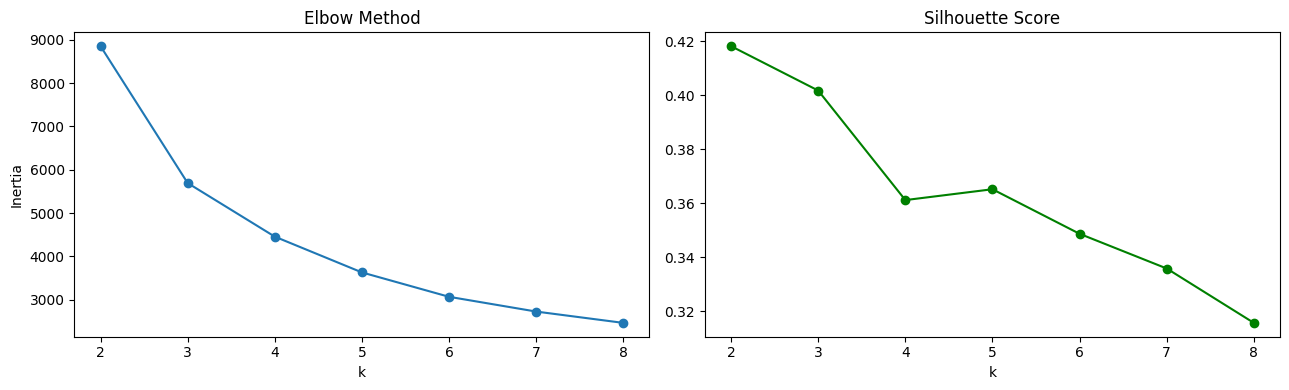

In [ ]:
# Cell 9 — Marketing ML: K-Means clustering on RFM + Decision Tree explanation
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

# ---- Build RFM from the customer table ----
snap = df_customers['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df_customers.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda x: (snap - x.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('TotalPrice', 'sum')).reset_index()

# ---- Scale (log-transform first: RFM is heavily skewed) ----
X = rfm[['Recency','Frequency','Monetary']].copy()
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary']  = np.log1p(X['Monetary'])
Xs = StandardScaler().fit_transform(X)

# ---- Elbow + silhouette to justify k ----
inertia, sil = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(range(2,9), inertia, 'o-'); ax[0].set_title('Elbow Method'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(range(2,9), sil, 'o-', color='green'); ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

# ---- Fit final model: k=4 (matches our 4 personas) ----
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xs)
rfm['Cluster'] = km.labels_

# ---- Profile clusters ----
profile = rfm.groupby('Cluster').agg(
    Customers=('Customer ID','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'))

In [ ]:
# Cell 10 — Setup + Preprocessing following Chen et al. (2012)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

# --- Follow the paper's preprocessing choices ---
# Paper: 2011 only, UK only, aggregate to customer level (they used postcode)
d = df_clean[(df_clean['InvoiceDate'].dt.year == 2011) &
             (df_clean['Country'] == 'United Kingdom')].copy()

print(f"2011 UK transactions : {len(d):,}")
print(f"Unique customers     : {d['Customer ID'].nunique():,}")
print(f"Unique invoices      : {d['Invoice'].nunique():,}")
print(f"Avg items per invoice: {len(d)/d['Invoice'].nunique():.1f}")
# NOTE: paper segments by postcode; we use Customer ID as the closest available
# identifier. Document this as a methodological adaptation in your report.

2011 UK transactions : 440,256
Unique customers     : 3,808
Unique invoices      : 16,462
Avg items per invoice: 26.7


In [ ]:
# Cell 11 — Build RFM table (Recency in months, like the paper)
snapshot = d['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = d.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot - x.max()).days / 30.0),  # months
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')).reset_index()

print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

       Recency  Frequency   Monetary
count  3808.00    3808.00    3808.00
mean      2.82       4.02    1771.71
std       2.99       6.54    7080.60
min       0.03       1.00       3.75
25%       0.57       1.00     290.59
50%       1.57       2.00     634.34
75%       4.27       4.00    1531.76
max      11.33     171.00  231822.69


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

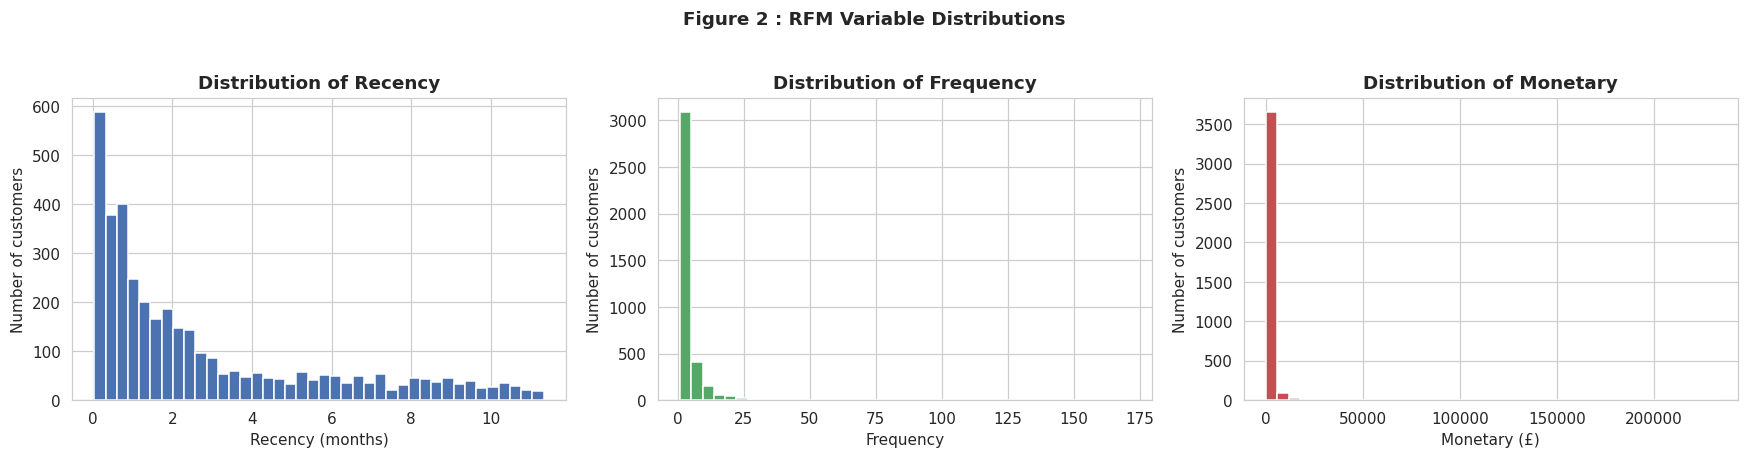

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Cell 12 — RFM DISTRIBUTIONS (histograms)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(['Recency','Frequency','Monetary']):
    ax[i].hist(rfm[col], bins=40, color=['#4C72B0','#55A868','#C44E52'][i], edgecolor='white')
    ax[i].set_title(f'Distribution of {col}', fontweight='bold')
    ax[i].set_xlabel(f'{col}' + (' (months)' if col=='Recency' else ' (£)' if col=='Monetary' else ''))
    ax[i].set_ylabel('Number of customers')
plt.suptitle('Figure 2 : RFM Variable Distributions', y=1.03, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# Cell 13 — Filter rare values (paper: 1% cutoff) + normalize
q_hi = rfm['Monetary'].quantile(0.99)
f_hi = rfm['Frequency'].quantile(0.99)
rfm_f = rfm[(rfm['Monetary'] <= q_hi) & (rfm['Frequency'] <= f_hi)].copy()
print(f"Removed {len(rfm)-len(rfm_f)} rare/outlier customers -> {len(rfm_f)} remain")

# Standard range transformation = MinMax scaling (paper's choice)
X = MinMaxScaler().fit_transform(rfm_f[['Recency','Frequency','Monetary']])

Removed 56 rare/outlier customers -> 3752 remain


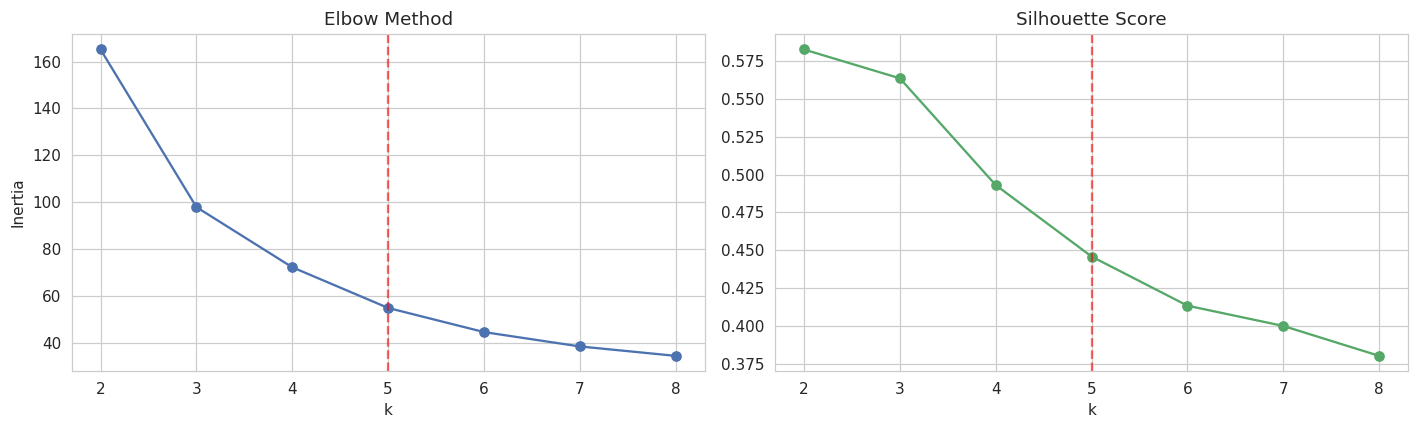

In [ ]:
# Cell 14 — Choose k: elbow + silhouette (paper tested 3,4,5 and chose 5)
inertia, sil = [], []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(K, inertia, 'o-', color='#4C72B0'); ax[0].axvline(5, ls='--', color='red', alpha=.6)
ax[0].set_title('Elbow Method'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(K, sil, 'o-', color='#55A868'); ax[1].axvline(5, ls='--', color='red', alpha=.6)
ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()
# Paper chose k=5 for clearest interpretation — we follow suit.

In [ ]:
# Cell 15 — K-MEANS with k=5 + cluster profile table (paper's Tables 6 & 7)
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X)
rfm_f['Cluster'] = km.labels_

profile = rfm_f.groupby('Cluster').agg(
    Customers=('Customer ID','count'),
    Recency=('Recency','median'),
    Frequency=('Frequency','median'),
    Monetary=('Monetary','median'),
    Total_Revenue=('Monetary','sum')).round(2)
profile['% Customers'] = (profile['Customers']/len(rfm_f)*100).round(1)
profile['% Revenue']   = (profile['Total_Revenue']/rfm_f['Monetary'].sum()*100).round(1)
print(profile)

# Map clusters -> personas by behaviour (best RFM = Champions)
rank = (-profile['Recency'].rank() + profile['Frequency'].rank() + profile['Monetary'].rank())
order = rank.sort_values(ascending=False).index.tolist()
personas = ['Champions','Loyal Customers','Regular','At Risk','Lost']
cluster_persona = {c: personas[i] for i, c in enumerate(order)}
rfm_f['Persona'] = rfm_f['Cluster'].map(cluster_persona)
print("\nPersona mapping:", cluster_persona)

         Customers  Recency  Frequency  Monetary  Total_Revenue  % Customers  \
Cluster                                                                        
0              628     5.00        2.0    381.75      382483.05         16.7   
1              691     0.53        6.0   2207.13     1701343.48         18.4   
2             1740     1.17        2.0    523.62     1176082.89         46.4   
3              524     8.82        1.0    266.12      190304.11         14.0   
4              169     0.23       15.0   5982.85     1145995.98          4.5   

         % Revenue  
Cluster             
0              8.3  
1             37.0  
2             25.6  
3              4.1  
4             24.9  

Persona mapping: {4: 'Champions', 1: 'Loyal Customers', 2: 'Regular', 0: 'At Risk', 3: 'Lost'}


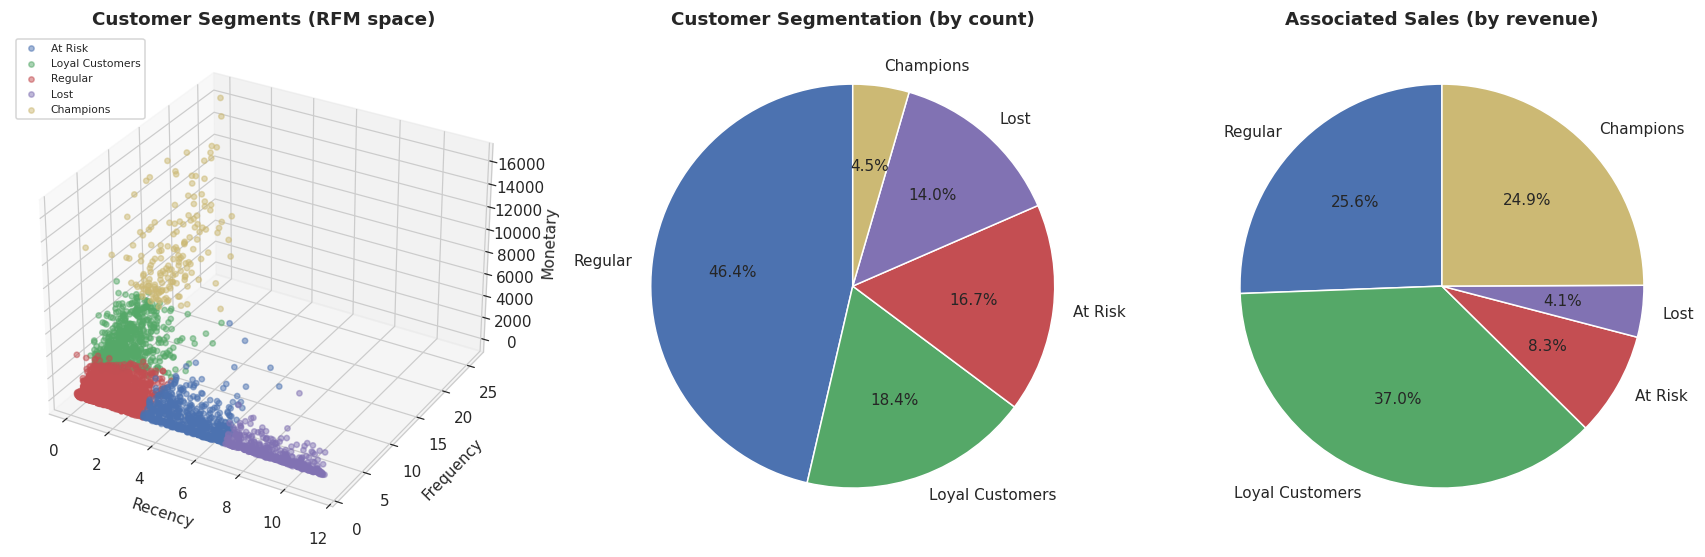

In [ ]:
# Cell 16 — CLUSTER VISUALS: 3D scatter + segment size/revenue pies
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 5))

# 3D scatter of clusters
ax1 = fig.add_subplot(131, projection='3d')
colors = ['#4C72B0','#55A868','#C44E52','#8172B3','#CCB974']
for c in sorted(rfm_f['Cluster'].unique()):
    s = rfm_f[rfm_f['Cluster']==c]
    ax1.scatter(s['Recency'], s['Frequency'], s['Monetary'],
                s=12, alpha=.5, color=colors[c], label=cluster_persona[c])
ax1.set_xlabel('Recency'); ax1.set_ylabel('Frequency'); ax1.set_zlabel('Monetary')
ax1.set_title('Customer Segments (RFM space)', fontweight='bold')
ax1.legend(fontsize=7, loc='upper left')

# Pie: customers per segment
ax2 = fig.add_subplot(132)
seg_size = rfm_f['Persona'].value_counts()
ax2.pie(seg_size, labels=seg_size.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Customer Segmentation (by count)', fontweight='bold')

# Pie: revenue per segment
ax3 = fig.add_subplot(133)
seg_rev = rfm_f.groupby('Persona')['Monetary'].sum().reindex(seg_size.index)
ax3.pie(seg_rev, labels=seg_rev.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('Associated Sales (by revenue)', fontweight='bold')

plt.tight_layout(); plt.show()

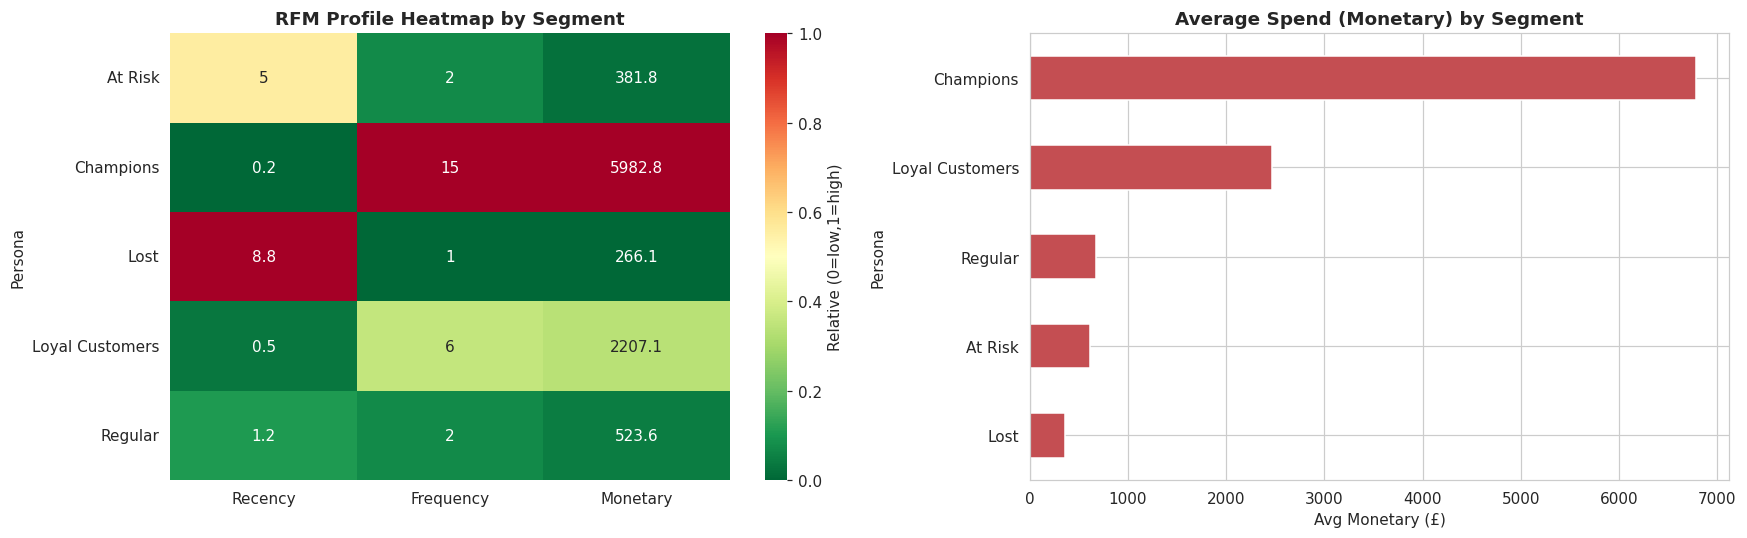

In [ ]:
# Cell 17 — Segment profile heatmap + bar charts of R, F, M by cluster
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of median RFM per persona (normalized 0-1 per column for comparability)
hm = rfm_f.groupby('Persona')[['Recency','Frequency','Monetary']].median()
hm_norm = (hm - hm.min()) / (hm.max() - hm.min())
sns.heatmap(hm_norm, annot=hm.round(1), fmt='g', cmap='RdYlGn_r',
            cbar_kws={'label':'Relative (0=low,1=high)'}, ax=ax[0])
ax[0].set_title('RFM Profile Heatmap by Segment', fontweight='bold')

# Grouped bar of avg monetary & frequency
prof2 = rfm_f.groupby('Persona').agg(Frequency=('Frequency','mean'),
                                     Monetary=('Monetary','mean'))
prof2['Monetary'].sort_values().plot(kind='barh', ax=ax[1], color='#C44E52')
ax[1].set_title('Average Spend (Monetary) by Segment', fontweight='bold')
ax[1].set_xlabel('Avg Monetary (£)')
plt.tight_layout(); plt.show()

Tree accuracy vs clusters: 96.2%

|--- Recency <= 3.15
|   |--- Frequency <= 4.50
|   |   |--- Monetary <= 2255.99
|   |   |   |--- class: 2
|   |   |--- Monetary >  2255.99
|   |   |   |--- class: 1
|   |--- Frequency >  4.50
|   |   |--- Frequency <= 11.50
|   |   |   |--- class: 1
|   |   |--- Frequency >  11.50
|   |   |   |--- class: 4
|--- Recency >  3.15
|   |--- Recency <= 6.95
|   |   |--- Monetary <= 3033.72
|   |   |   |--- class: 0
|   |   |--- Monetary >  3033.72
|   |   |   |--- class: 1
|   |--- Recency >  6.95
|   |   |--- Frequency <= 7.00
|   |   |   |--- class: 3
|   |   |--- Frequency >  7.00
|   |   |   |--- class: 0



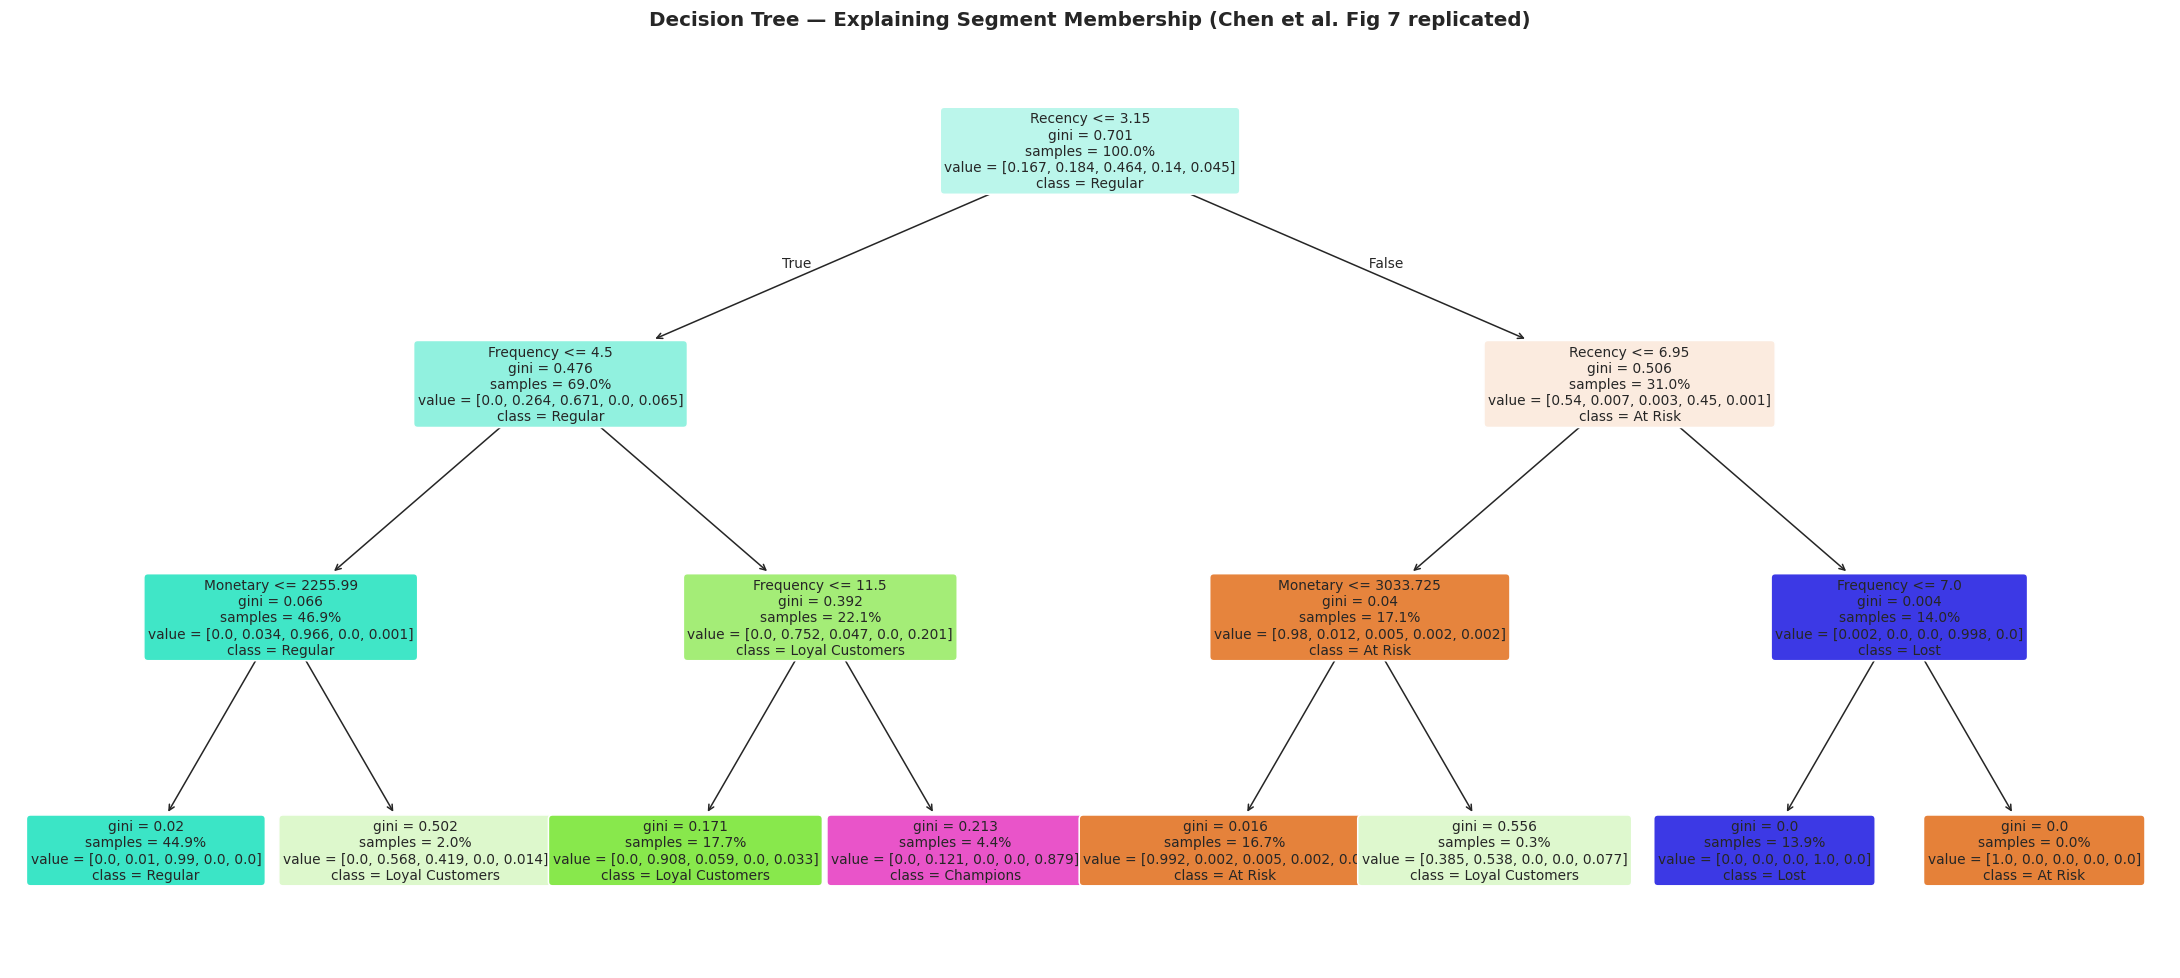

In [ ]:
# Cell 18 — DECISION TREE: enhancing clustering
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(rfm_f[['Recency','Frequency','Monetary']], rfm_f['Cluster'])
print(f"Tree accuracy vs clusters: {dt.score(rfm_f[['Recency','Frequency','Monetary']], rfm_f['Cluster']):.1%}\n")
print(export_text(dt, feature_names=['Recency','Frequency','Monetary']))

plt.figure(figsize=(20, 9))
plot_tree(dt, feature_names=['Recency','Frequency','Monetary'],
          class_names=[cluster_persona[i] for i in sorted(cluster_persona)],
          filled=True, rounded=True, fontsize=9, proportion=True)
plt.title('Decision Tree — Explaining Segment Membership (Chen et al. Fig 7 replicated)',
          fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# Cell 19 — Market Basket Analysis (Apriori): products bought together
# In Colab, install once:  !pip install mlxtend -q
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

# --- Build the basket: focus on UK (85% of revenue), top 300 products ---
# (Capping products keeps the invoice×product matrix small enough for Colab memory)
uk = df_clean[df_clean['Country'] == 'United Kingdom'].copy()
top_prods = uk['Description'].value_counts().head(300).index
uk = uk[uk['Description'].isin(top_prods)]

basket = (uk.groupby(['Invoice','Description'])['Quantity']
            .sum().unstack().fillna(0) > 0)   # True/False per product per invoice
print(f"Basket matrix: {basket.shape[0]:,} invoices × {basket.shape[1]} products")

# --- Frequent itemsets + association rules ---
items = apriori(basket, min_support=0.02, use_colnames=True, max_len=3, low_memory=True)
rules = association_rules(items, metric='lift', min_threshold=2).sort_values('lift', ascending=False)

rules['Antecedent'] = rules['antecedents'].apply(lambda x: ', '.join(x))
rules['Consequent'] = rules['consequents'].apply(lambda x: ', '.join(x))
basket_rules = rules[['Antecedent','Consequent','support','confidence','lift']].round(3)

print(f"\nFound {len(basket_rules)} association rules (lift ≥ 2)\n")
print(basket_rules.head(12).to_string(index=False))

Basket matrix: 31,972 invoices × 300 products

Found 104 association rules (lift ≥ 2)

                                                       Antecedent                                                        Consequent  support  confidence   lift
GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER                                     PINK REGENCY TEACUP AND SAUCER    0.021       0.707 24.071
                                   PINK REGENCY TEACUP AND SAUCER GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER     0.021       0.704 24.071
 PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER                                    GREEN REGENCY TEACUP AND SAUCER    0.021       0.902 23.402
                                  GREEN REGENCY TEACUP AND SAUCER  PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER     0.021       0.537 23.402
                                   PINK REGENCY TEACUP AND SAUCER                                   GREEN REGENCY

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

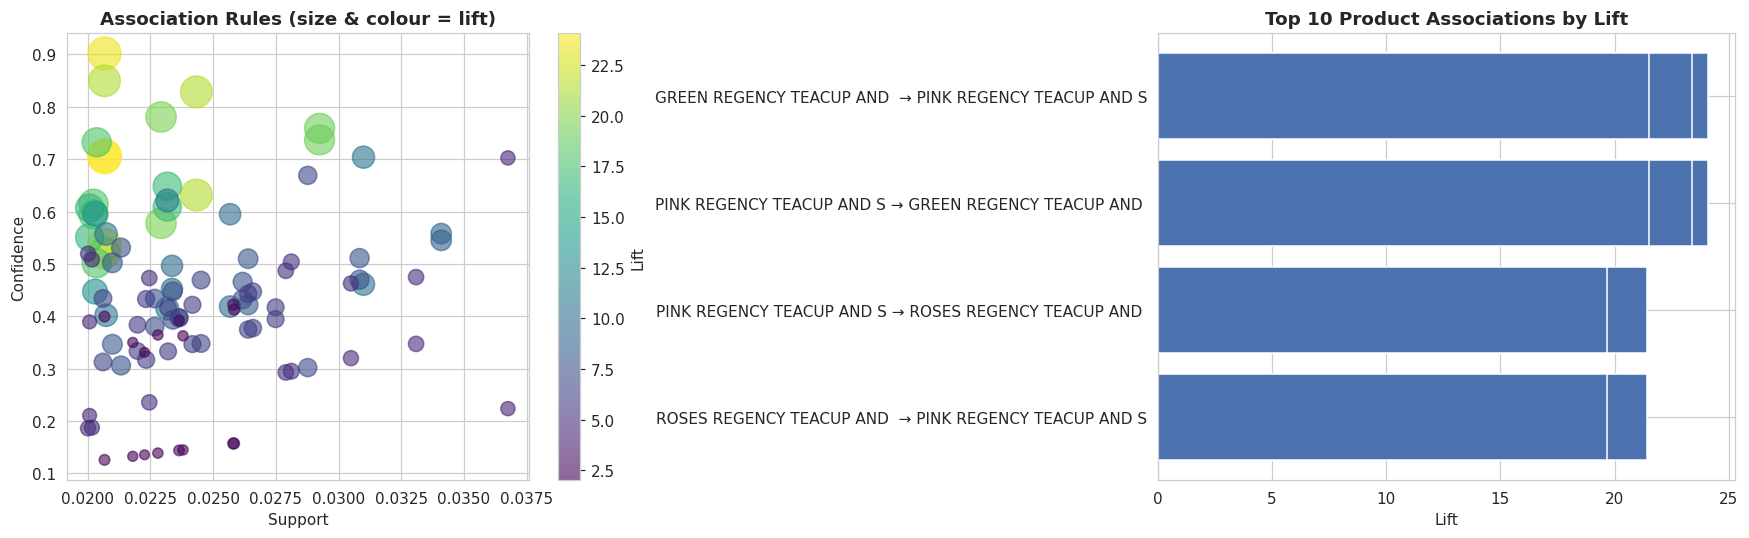

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Cell 20 — Visualize the basket rules
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 1. Scatter: support vs confidence, sized/coloured by lift (classic MBA plot)
sc = ax[0].scatter(rules['support'], rules['confidence'],
                   s=rules['lift']*20, c=rules['lift'], cmap='viridis', alpha=.6)
ax[0].set_xlabel('Support'); ax[0].set_ylabel('Confidence')
ax[0].set_title('Association Rules (size & colour = lift)', fontweight='bold')
plt.colorbar(sc, ax=ax[0], label='Lift')

# 2. Top 10 rules by lift, as a horizontal bar
top10 = basket_rules.head(10).copy()
top10['Rule'] = (top10['Antecedent'].str.slice(0,25) + ' → ' + top10['Consequent'].str.slice(0,25))
ax[1].barh(top10['Rule'], top10['lift'], color='#4C72B0')
ax[1].invert_yaxis(); ax[1].set_xlabel('Lift')
ax[1].set_title('Top 10 Product Associations by Lift', fontweight='bold')

plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Found 121 unique cross-sell pairs (lift >= 1.5)
                                 A                                   B      lift
       SET/6 RED SPOTTY PAPER CUPS       SET/6 RED SPOTTY PAPER PLATES 31.405138
WOODEN STAR CHRISTMAS SCANDINAVIAN WOODEN HEART CHRISTMAS SCANDINAVIAN 30.707972
 GARDENERS KNEELING PAD KEEP CALM   GARDENERS KNEELING PAD CUP OF TEA  26.645154
    PINK REGENCY TEACUP AND SAUCER     GREEN REGENCY TEACUP AND SAUCER 22.308063
       RED RETROSPOT CHARLOTTE BAG         CHARLOTTE BAG PINK POLKADOT 21.684753
    PINK REGENCY TEACUP AND SAUCER    ROSES REGENCY TEACUP AND SAUCER  20.404940
  ROSES REGENCY TEACUP AND SAUCER      GREEN REGENCY TEACUP AND SAUCER 19.837998
               SPACEBOY LUNCH BOX                 DOLLY GIRL LUNCH BOX 18.750731
                 TOILET METAL SIGN                 BATHROOM METAL SIGN 18.713848
         ALARM CLOCK BAKELIKE RED           ALARM CLOCK BAKELIKE GREEN 17.670139


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

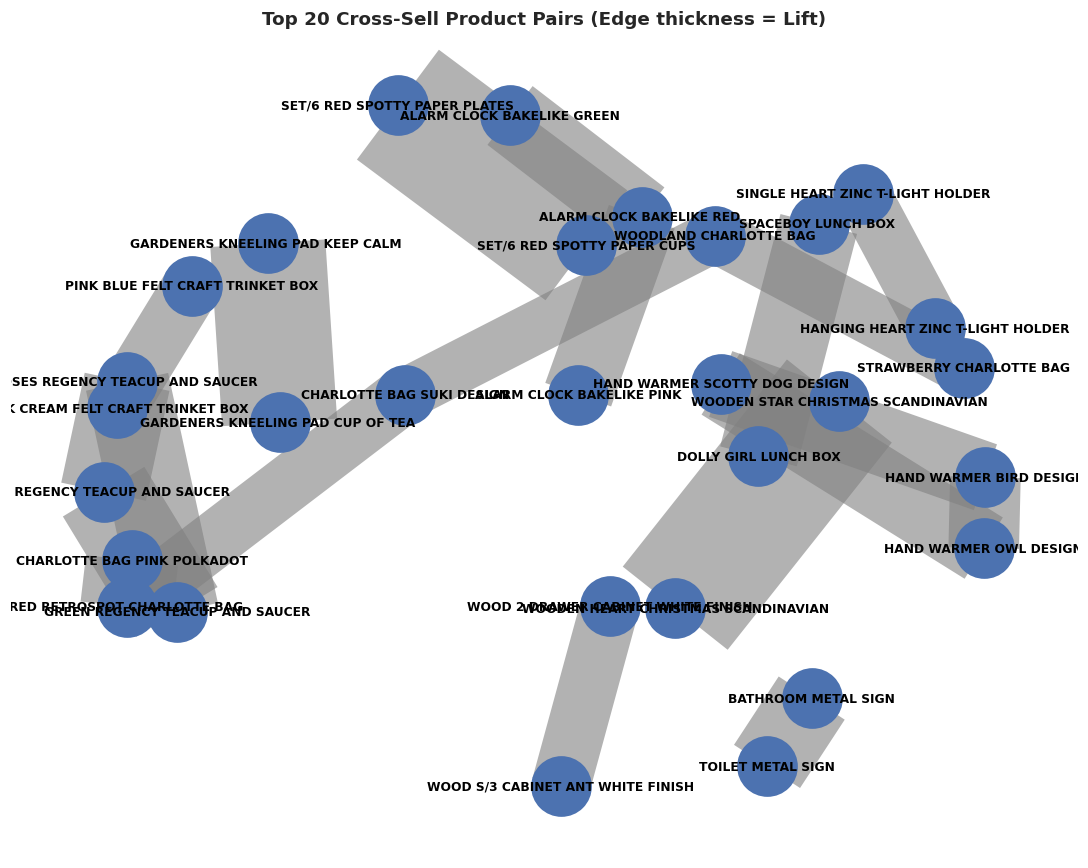

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Cell 21 — Full-catalog cross-sell map for shelf/placement decisions
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
import pandas as pd

# --- Wider basket: top 500 UK products ---
uk = df_clean[df_clean['Country'] == 'United Kingdom'].copy()
top_prods = uk['Description'].value_counts().head(500).index
uk = uk[uk['Description'].isin(top_prods)]
basket = (uk.groupby(['Invoice','Description'])['Quantity']
            .sum().unstack().fillna(0) > 0)

# --- Rules: single-item pairs only, for clean placement decisions ---
items = apriori(basket, min_support=0.015, use_colnames=True, max_len=2, low_memory=True)
rules = association_rules(items, metric='lift', min_threshold=1.5)
rules = rules[(rules['antecedents'].apply(len)==1) & (rules['consequents'].apply(len)==1)]
rules['A'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['B'] = rules['consequents'].apply(lambda x: list(x)[0])
rules = rules.sort_values('lift', ascending=False)

# --- Deduplicate mirror pairs (A→B == B→A for a shelf) ---
seen, pairs = set(), []
for _, r in rules.iterrows():
    key = frozenset([r['A'], r['B']])
    if key not in seen:
        pairs.append(r)
        seen.add(key)
pairs = pd.DataFrame(pairs)

print(f"Found {len(pairs)} unique cross-sell pairs (lift >= 1.5)")
print(pairs[['A','B','lift']].head(10).to_string(index=False))

# --- NETWORK GRAPH: visualize the top N pairs ---
plt.figure(figsize=(10, 8))
colors = ['#4C72B0','#55A868','#C44E52','#8172B3','#CCB974','#64B5CD']

G = nx.from_pandas_edgelist(pairs.head(20), 'A', 'B', ['lift'])
pos = nx.spring_layout(G, k=0.8, iterations=50)
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color=colors[0])
nx.draw_networkx_edges(G, pos, width=[(d['lift']-1.5)*3 for (u,v,d) in G.edges(data=True)],
                       edge_color='grey', alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='black', font_weight='bold')

plt.title('Top 20 Cross-Sell Product Pairs (Edge thickness = Lift)', fontweight='bold')
plt.axis('off')
plt.tight_layout(); plt.show()


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# also silence the Jupyter/IPython deprecation noise specifically
import logging
logging.getLogger('py.warnings').setLevel(logging.ERROR)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Cell 22 — Interactive dashboard (Plotly) — runs inline in Colab
# !pip install plotly -q   (run once if needed)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd

# Palette tuned to a gifting retailer — muted, editorial, not stock-dashboard blue
C = {'plum':'#5b3a56','clay':'#b5654a','sage':'#6b7d5c','gold':'#c39a4b','slate':'#4a6076','muted':'#8a8375'}
PERSONA_COLORS = {'Champions':C['gold'],'Loyal Customers':C['plum'],'Regular':C['sage'],
                  'At Risk':C['clay'],'Lost':C['muted']}

# --- Rebuild the small aggregate tables from your existing frames ---
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
monthly = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
country = (df_clean.groupby('Country')['TotalPrice'].sum()
           .sort_values(ascending=False).reset_index())
seg = rfm_f.groupby('Persona').agg(Customers=('Customer ID','count'),
        Revenue=('Monetary','sum'), Recency=('Recency','median'),
        Frequency=('Frequency','median'), Monetary=('Monetary','median')).reset_index()

In [ ]:
# Cell 23 — KPI + trend + geography (Executive view)
total_rev = df_clean['TotalPrice'].sum()
kpis = {'Revenue':f"£{total_rev/1e6:.1f}M", 'Customers':f"{df_clean['Customer ID'].nunique():,}",
        'Orders':f"{df_clean['Invoice'].nunique():,}", 'AOV':f"£{df_clean.groupby('Invoice')['TotalPrice'].sum().mean():.0f}"}
print(" | ".join(f"{k}: {v}" for k,v in kpis.items()))

fig = make_subplots(rows=1, cols=2, column_widths=[0.6,0.4],
                    subplot_titles=("Monthly Revenue Trend","Top Markets by Revenue"),
                    specs=[[{"type":"scatter"},{"type":"bar"}]])

fig.add_trace(go.Scatter(x=monthly['YearMonth'], y=monthly['TotalPrice'], mode='lines',
    line=dict(color=C['clay'], width=2.5), fill='tozeroy',
    fillcolor='rgba(181,101,74,0.08)', name='Revenue',
    hovertemplate='%{x}<br>£%{y:,.0f}<extra></extra>'), row=1, col=1)

top_c = country[country['Country']!='United Kingdom'].head(8)
fig.add_trace(go.Bar(y=top_c['Country'], x=top_c['TotalPrice'], orientation='h',
    marker_color=C['sage'], name='Revenue',
    hovertemplate='%{y}<br>£%{x:,.0f}<extra></extra>'), row=1, col=2)

fig.update_layout(height=420, showlegend=False, plot_bgcolor='#fffdf8', paper_bgcolor='#fffdf8',
    font=dict(family='Inter, sans-serif', color=C['muted']),
    title_text="Executive Overview", title_font=dict(size=20, color='#1a1e2e'))
fig.update_yaxes(autorange="reversed", row=1, col=2)
fig.show()

Revenue: £19.7M | Customers: 5,852 | Orders: 39,530 | AOV: £497


In [ ]:
# Cell 24 — Interactive segment explorer with a working dropdown filter
metrics = {'Revenue':'Revenue','Customers':'Customers','Median Spend':'Monetary','Median Frequency':'Frequency'}
seg_sorted = seg.sort_values('Revenue', ascending=False)

fig = go.Figure()
# one bar trace per metric; dropdown toggles visibility
for i,(label,col) in enumerate(metrics.items()):
    fig.add_trace(go.Bar(x=seg_sorted['Persona'], y=seg_sorted[col],
        marker_color=[PERSONA_COLORS[p] for p in seg_sorted['Persona']],
        visible=(i==0), name=label,
        hovertemplate='%{x}<br>%{y:,.0f}<extra></extra>'))

buttons = [dict(label=label, method='update',
                args=[{'visible':[j==i for j in range(len(metrics))]},
                      {'title':f'Customer Segments — {label}'}])
           for i,label in enumerate(metrics)]

fig.update_layout(
    updatemenus=[dict(buttons=buttons, x=1.0, xanchor='right', y=1.18, yanchor='top',
                      bgcolor='#fffdf8', bordercolor=C['muted'])],
    title='Customer Segments - Revenue', height=460,
    plot_bgcolor='#fffdf8', paper_bgcolor='#fffdf8',
    font=dict(family='Inter, sans-serif', color=C['muted']))
fig.show()

In [ ]:
# Cell 25 — Segment scatter (RFM space) — interactive, hover for detail
fig = px.scatter(rfm_f, x='Recency', y='Monetary', size='Frequency', color='Persona',
                 color_discrete_map=PERSONA_COLORS, size_max=22, opacity=0.6,
                 hover_data={'Customer ID':True,'Frequency':True},
                 title='Customer Segments in RFM Space')
fig.update_layout(height=480, plot_bgcolor='#fffdf8', paper_bgcolor='#fffdf8',
                  font=dict(family='Inter, sans-serif', color=C['muted']))
fig.show()
# This is the interactive version of your 3D plot — 2D + hover reads far more clearly.

In [ ]:
# Cell 26 — Cross-sell table (interactive, sortable) + top products
# placement is your cross-sell DataFrame from Cell 21; fall back gracefully
try:
    cs = placement.head(12)
except NameError:
    cs = pd.DataFrame()  # run the market-basket cell first if this is empty

if not cs.empty:
    fig = go.Figure(data=[go.Table(
        columnwidth=[40,40,12],
        header=dict(values=['<b>Product 1</b>','<b>Product 2</b>','<b>Lift</b>'],
                    fill_color=C['plum'], font=dict(color='white', size=12), align='left'),
        cells=dict(values=[cs['Product 1'], cs['Product 2'], cs['lift']],
                   fill_color=[['#fffdf8','#f6f3ec']*6], align='left',
                   font=dict(size=11)))])
    fig.update_layout(title='Strongest Cross-Sell Pairs (by lift)', height=420)
    fig.show()